### 1. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.feature_selection import chi2, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder
from sklearn.metrics import accuracy_score

In [17]:
df=pd.read_csv('glass1.csv')


In [18]:
df.shape

(999, 10)

In [19]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [20]:
## info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB


In [21]:
## duplicates
df.duplicated().sum()

np.int64(785)

In [27]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [28]:
df.duplicated().sum()

np.int64(0)

In [34]:
col = df.select_dtypes(include=['float', 'int'])
df[col.columns] = col.fillna(col.mean())

In [35]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

<Axes: >

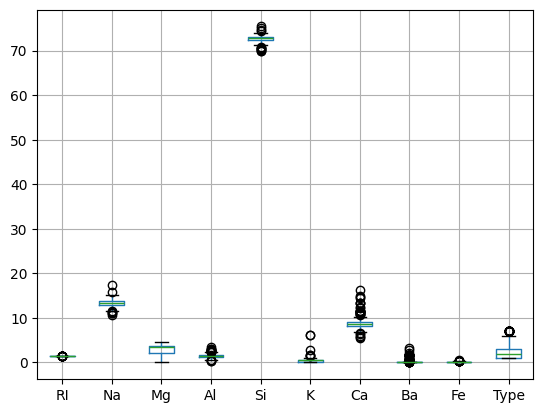

In [36]:
## detection of outlier
df.boxplot()

In [37]:
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+ 1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

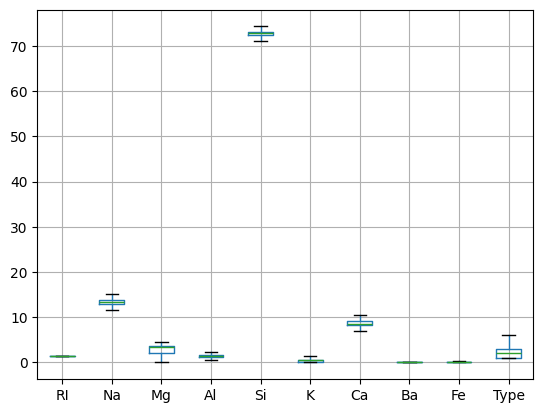

In [38]:
df.boxplot()
plt.show()

### 2: Data Visualization:
Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

In [41]:
features=df.drop(columns=['Type'])
target = df[['Type']]

In [45]:
### train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(171, 9)
(43, 9)
(171, 1)
(43, 1)


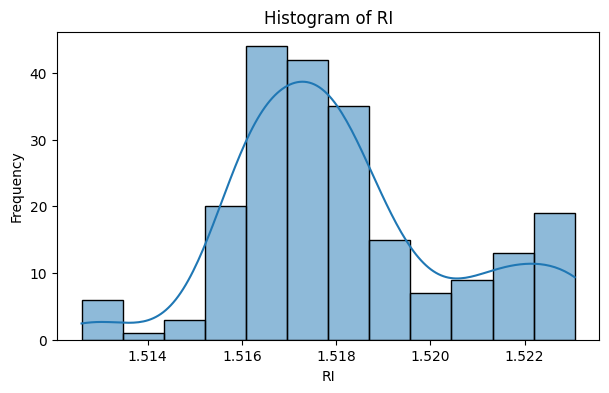

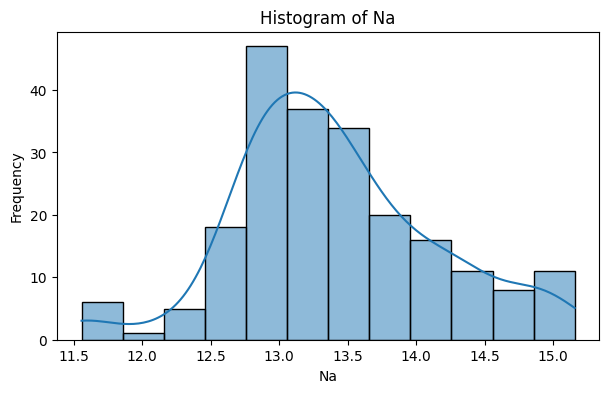

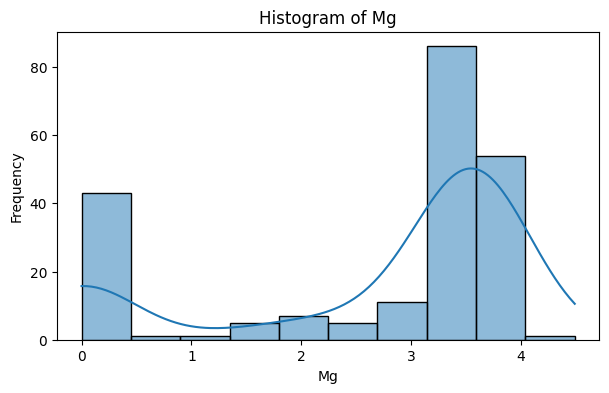

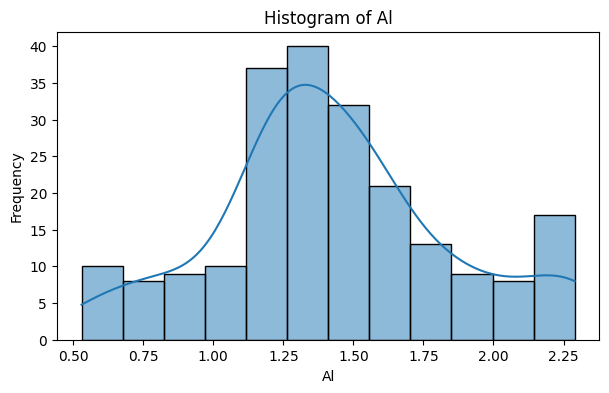

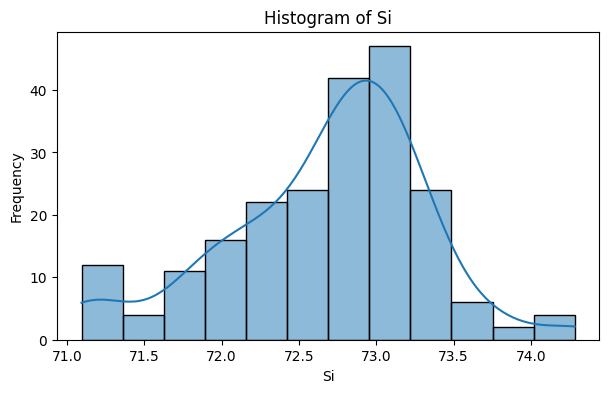

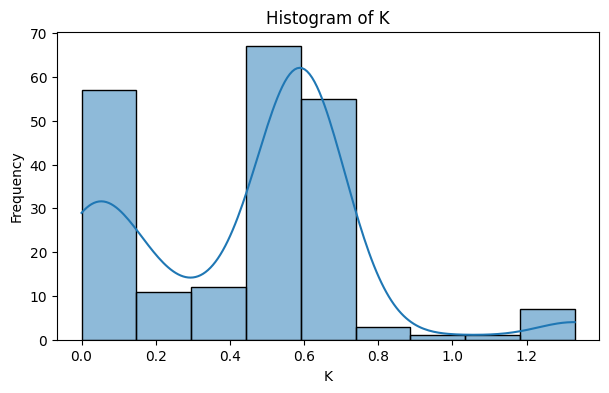

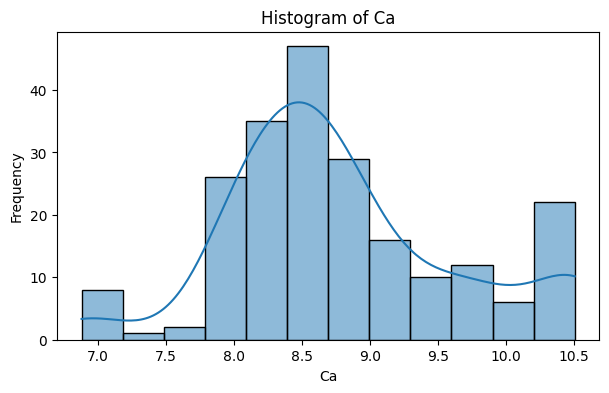

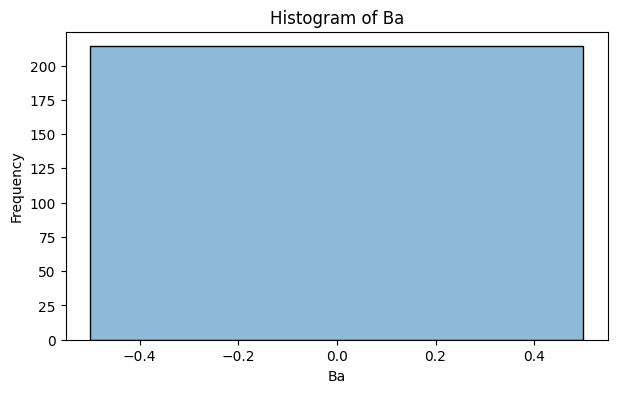

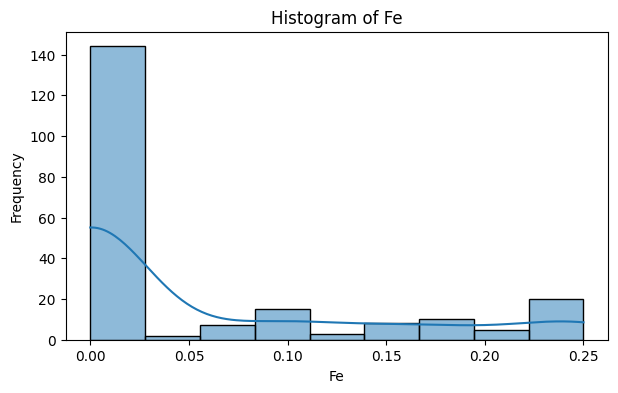

In [48]:
for col in features:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

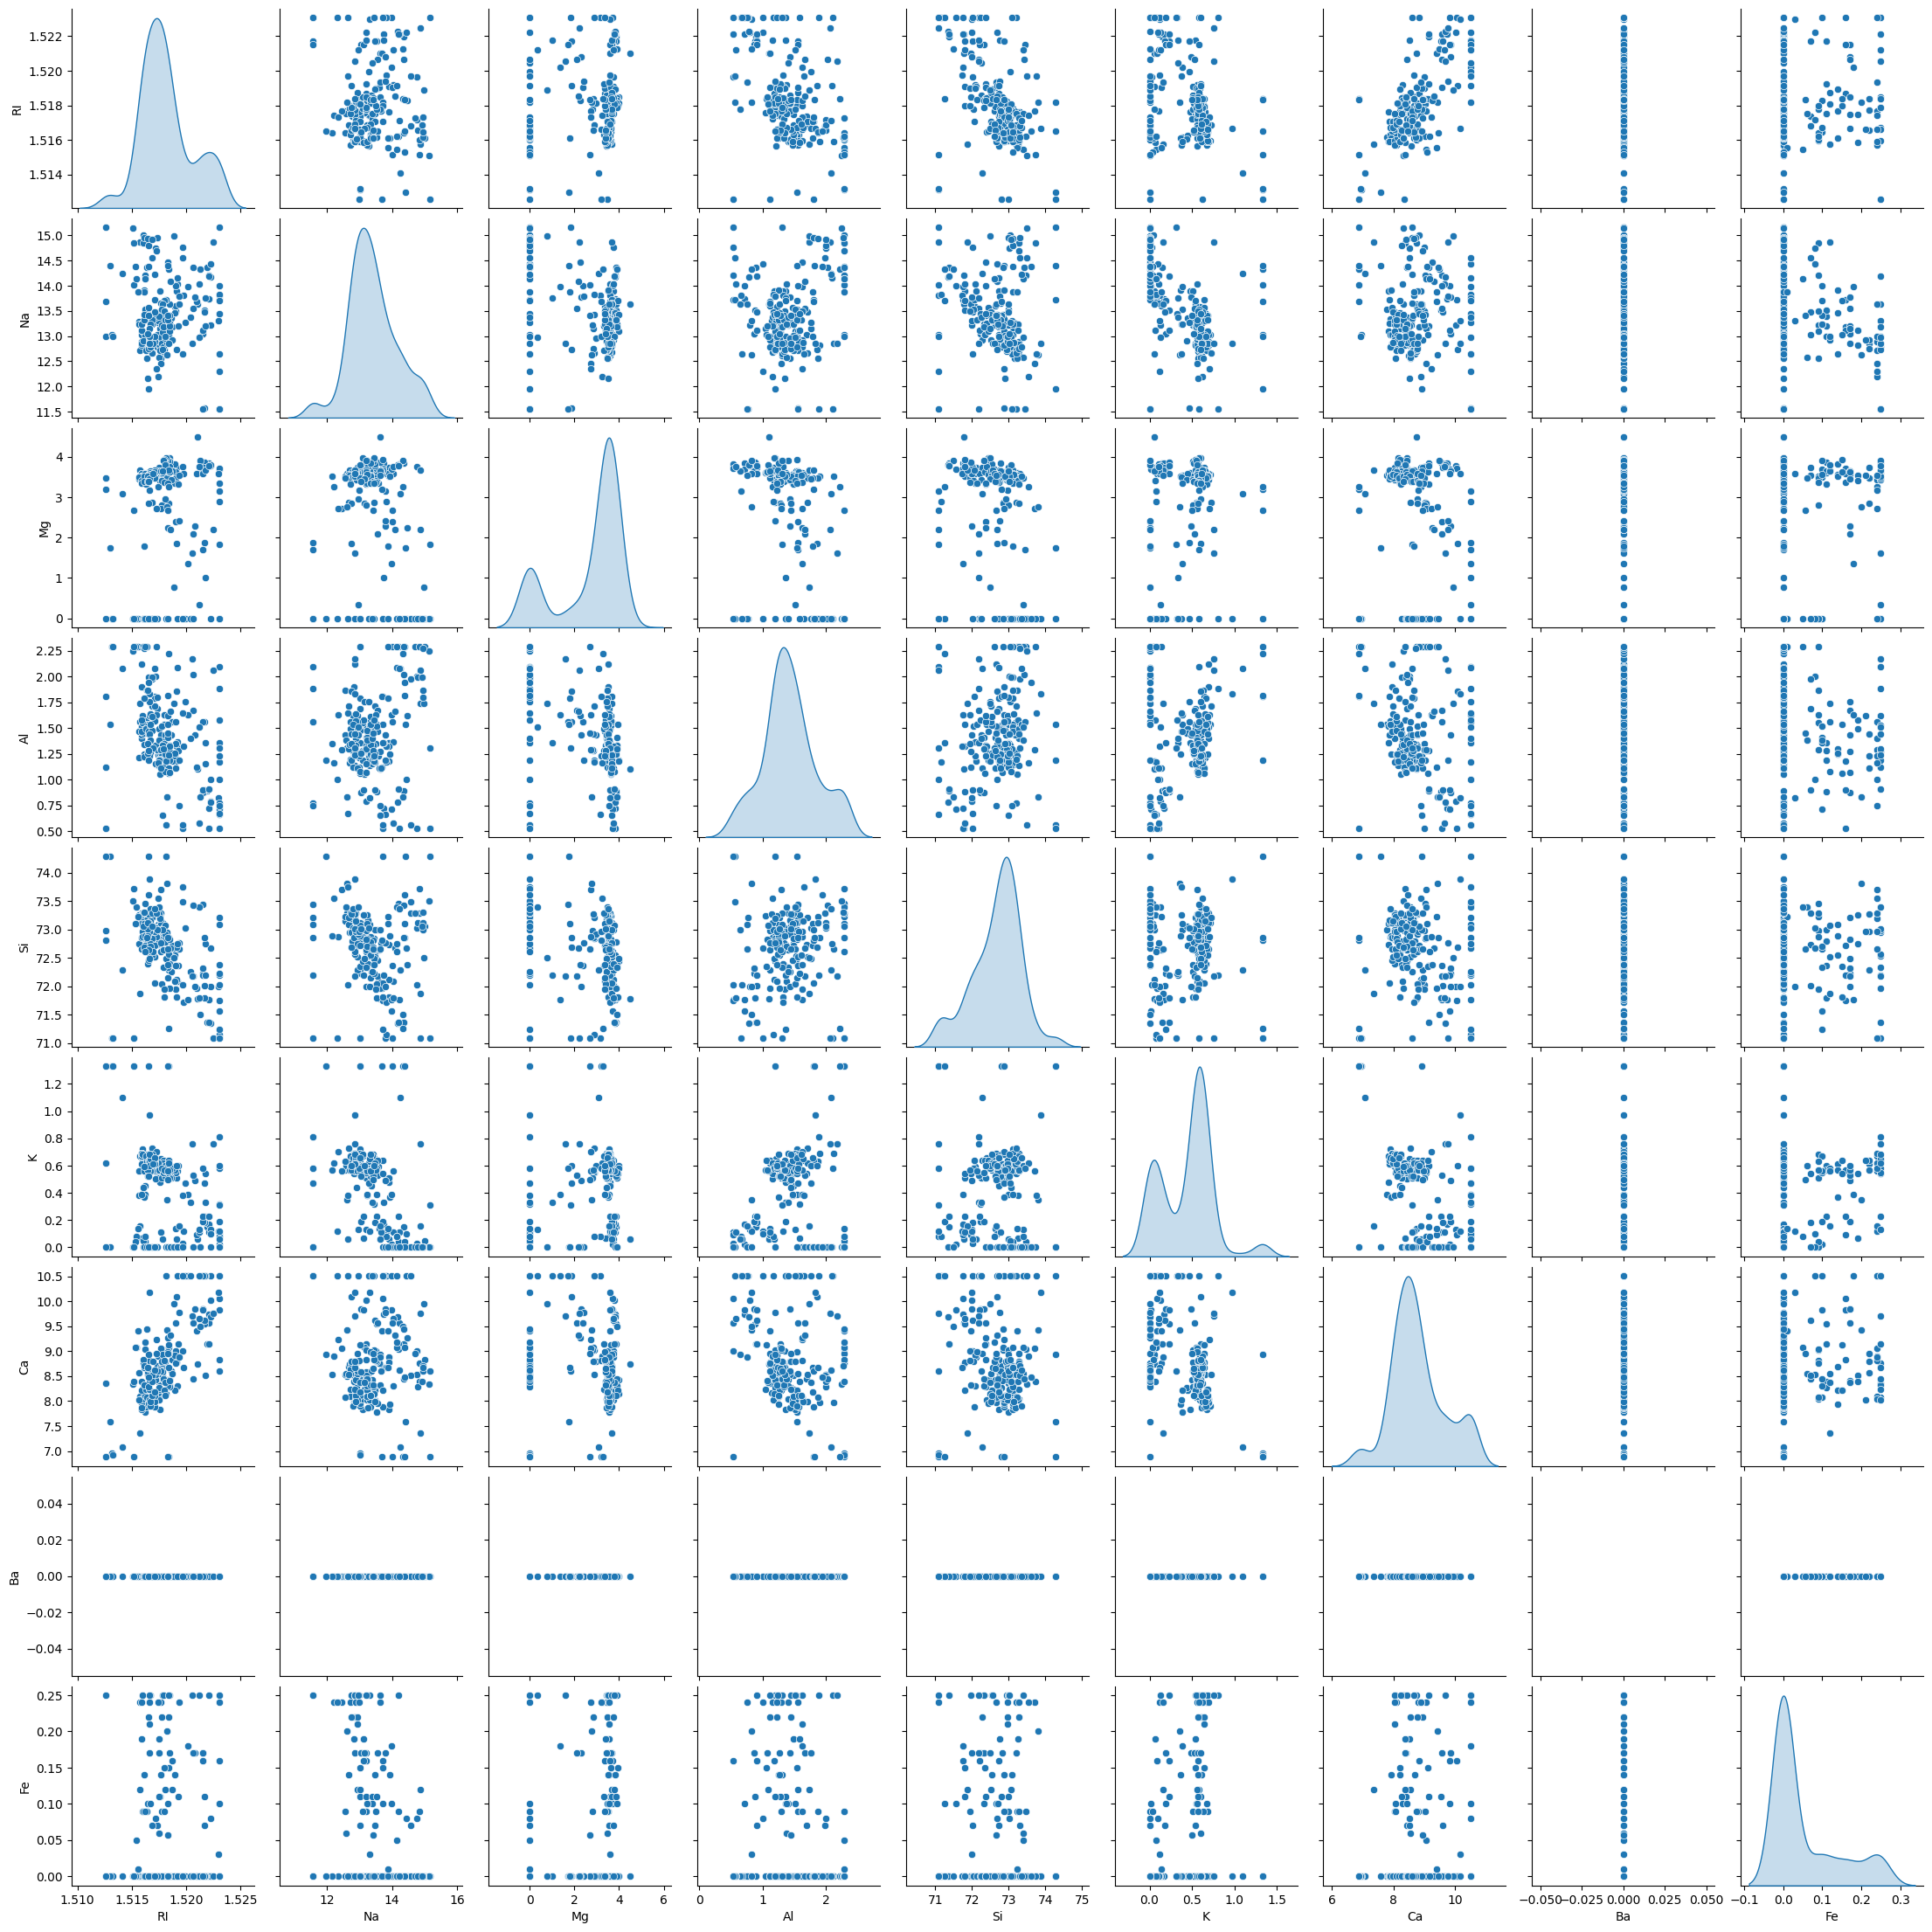

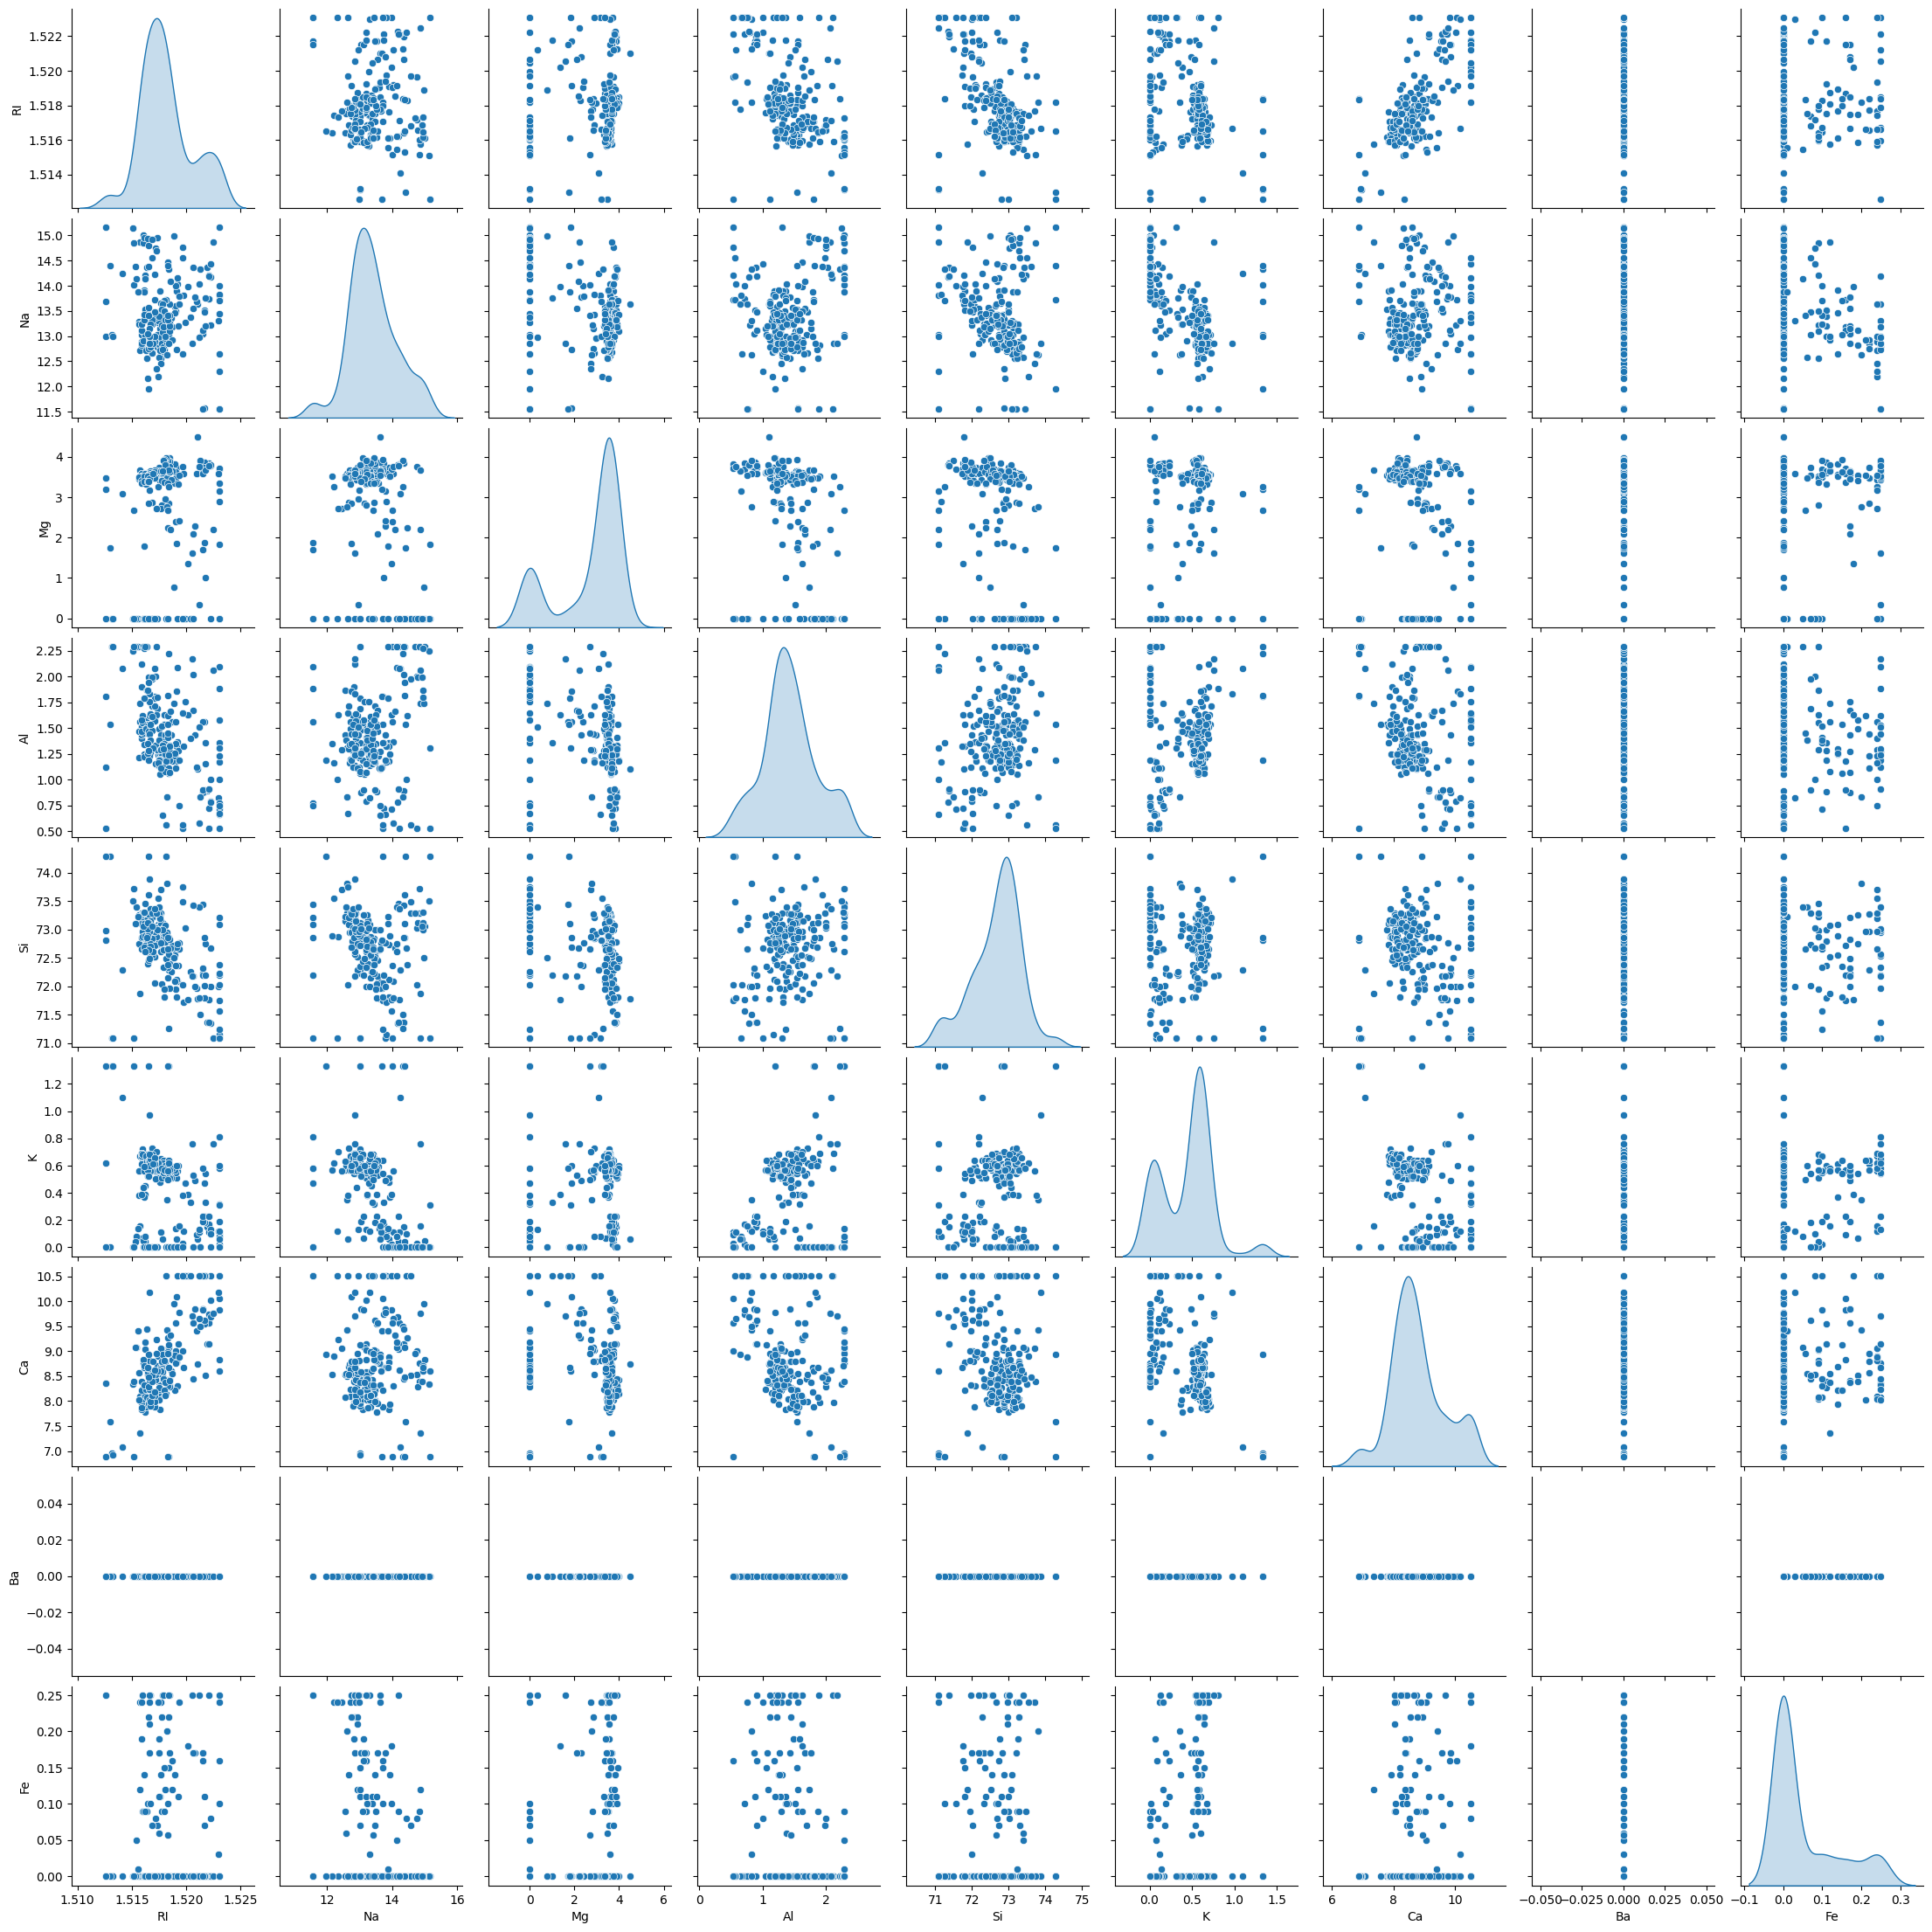

In [51]:
sns.pairplot(data=features,diag_kind='kde')
plt.show()

### 3: Data Preprocessing
1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.


In [53]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [54]:
### features selection
f_clas=f_classif(x_train,y_train)
f_clas

(array([ 1.62629652, 30.27779108, 46.77032563, 17.54872543,  2.4508535 ,
         5.76374851,  0.81493367,         nan,  2.4911135 ]),
 array([1.55735841e-01, 9.18939353e-22, 6.22314418e-30, 6.41995174e-14,
        3.58018101e-02, 6.24273294e-05, 5.40587388e-01,            nan,
        3.32329953e-02]))

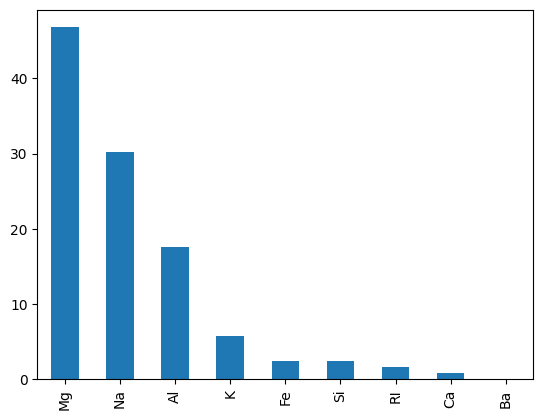

In [55]:
#### feature selection
f_clas= f_classif(x_train,y_train)
pd.Series(f_clas[0],index=x_train.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [56]:
x_train.drop(columns=['Ba','Ca'],inplace=True)
x_test.drop(columns=['Ba','Ca'],inplace=True)

In [57]:
x_train.head()

,RI,Na,Mg,Al,Si,K,Fe
3,1.51766,13.21,3.69,1.29,72.61,0.57,0.00
97,1.51689,12.67,2.88,1.71,73.21,0.73,0.00
85,1.51569,13.24,3.49,1.47,73.25,0.38,0.00
32,1.51775,12.85,3.48,1.23,72.97,0.61,0.22
207,1.51640,14.37,0.00,2.29,72.85,0.00,0.00


In [59]:
std_sca=StandardScaler()
x_train[['RI','Na','Mg','Al','Si','K','Fe']]=std_sca.fit_transform(x_train[['RI','Na','Mg','Al','Si','K','Fe']])
x_test[['RI','Na','Mg','Al','Si','K','Fe']]= std_sca.transform(x_test[['RI','Na','Mg','Al','Si','K','Fe']])

### 4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.


In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
rand_for=RandomForestClassifier(n_estimators=150,bootstrap=True,random_state=50,max_features='sqrt',
                               max_samples=0.9)

In [86]:
y_train = y_train.round().astype(int)
y_test = y_test.round().astype(int)

In [87]:
from sklearn.metrics import accuracy_score

rand_for.fit(x_train, y_train)
y_pred = rand_for.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7209302325581395


In [88]:
#### GridSearch
from sklearn.model_selection import GridSearchCV

In [89]:
params={'n_estimators':[50,100,150,200]}
grid_search=GridSearchCV(estimator=rand_for,param_grid=params,cv=10)
grid_search.fit(x_train,y_train)
grid_search.best_params_,grid_search.best_score_

({'n_estimators': 150}, np.float64(0.8127450980392157))

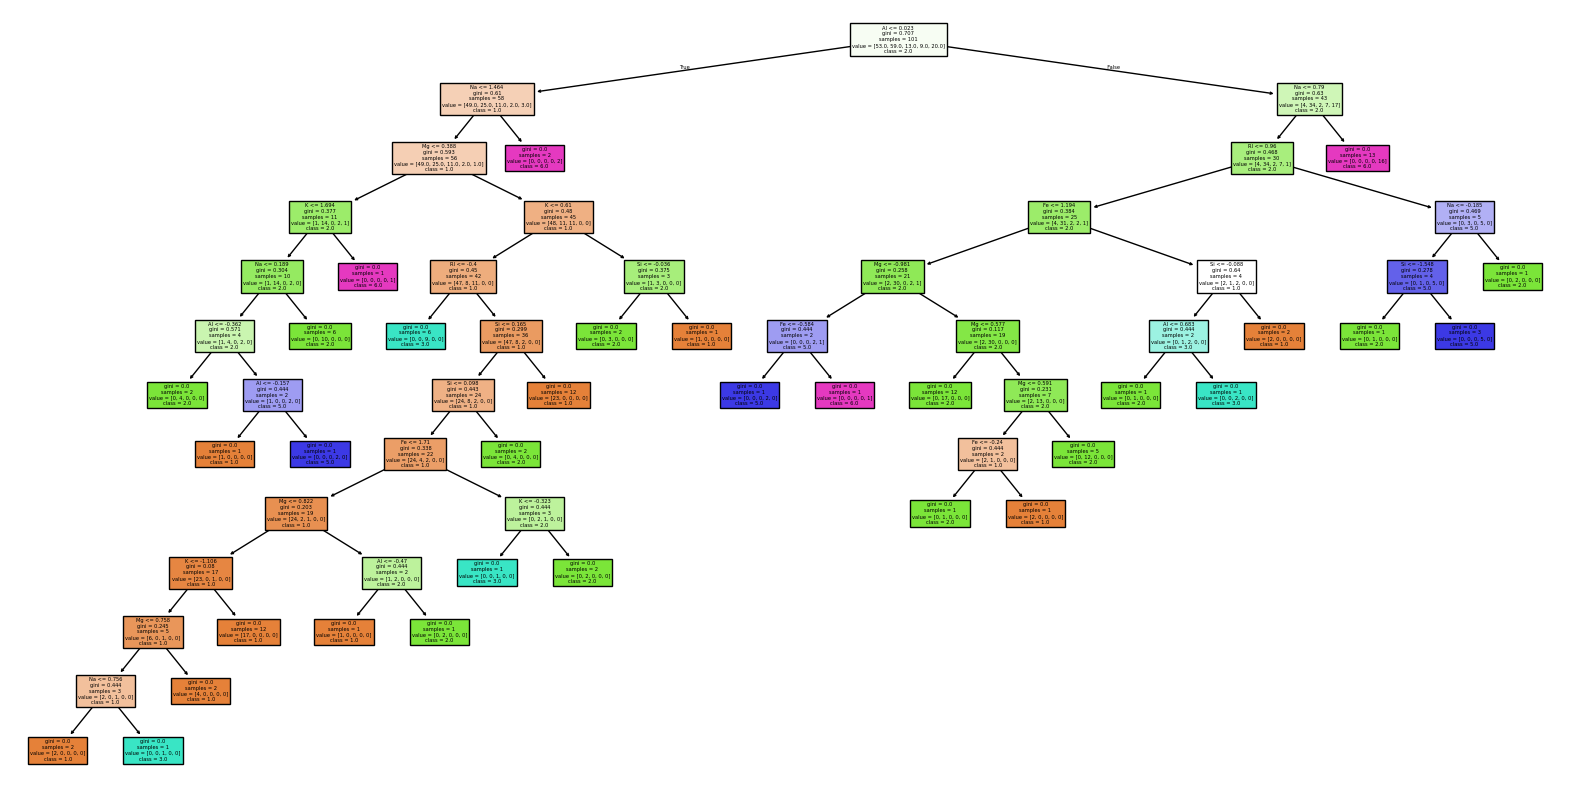

In [91]:
#### Plotting a tree
plt.figure(figsize=(20,10))
plot_tree(rand_for.estimators_[5],filled=True,feature_names=list(x_train),class_names=list(target['Type'].astype(str).unique()))
plt.show();

In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7209302325581395
Precision: 0.7500553709856036
Recall   : 0.7209302325581395
F1 Score : 0.7063462796645453


### 5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.

In [77]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

In [93]:
bag_class = BaggingClassifier(estimator=LogisticRegression(),n_estimators=50,max_samples=0.9,bootstrap=True,
                              bootstrap_features=True,max_features=0.9,random_state=50)

In [96]:
bag_class.fit(x_train,y_train)
y_pred=bag_class.predict(x_test)
accuracy_score(y_test,y_pred)

0.5813953488372093

In [95]:
params={'n_estimators':[50,100,150,200]}
grid_search=GridSearchCV(estimator=bag_class,param_grid=params,cv=10)
grid_search.fit(x_train,y_train)
grid_search.best_params_,grid_search.best_score_

({'n_estimators': 50}, np.float64(0.6614379084967321))

### Grient Boosting

In [102]:
from sklearn.ensemble import GradientBoostingClassifier
grad_boost= GradientBoostingClassifier(learning_rate=0.7,n_estimators=100, subsample=1.0,max_features=1,random_state=50)
grad_boost.fit(x_train,y_train)
y_pred= grad_boost.predict(x_test)
accuracy_score(y_test,y_pred)

0.6976744186046512

In [99]:
params= {'n_estimators':[100,150],'learning_rate':[0.5,0.7]}
grid_search= GridSearchCV(param_grid=params, estimator=grad_boost,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_,grid_search.best_score_

({'learning_rate': 0.7, 'n_estimators': 100}, np.float64(0.7426890756302521))